#### Simple linear regression

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [79]:
## read the dataset

df=pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

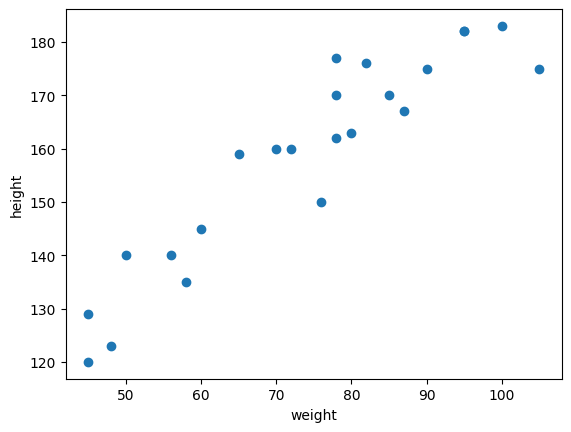

In [80]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("weight")
plt.ylabel("height")

In [81]:
 ## divide the dataset into independent and dependent features

X=df[['Weight']] # independent feature
y=df['Height'] # dependent feature

In [82]:
## train test split
from sklearn.model_selection import train_test_split

In [83]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [84]:
X.shape

(23, 1)

In [85]:
X_train.shape,X_test.shape

((18, 1), (5, 1))

In [86]:
y_train.shape,y_test.shape

((18,), (5,))

In [87]:
## standardize the dataset train independent data

from sklearn.preprocessing import StandardScaler

In [88]:
scaler=StandardScaler()

In [89]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [90]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

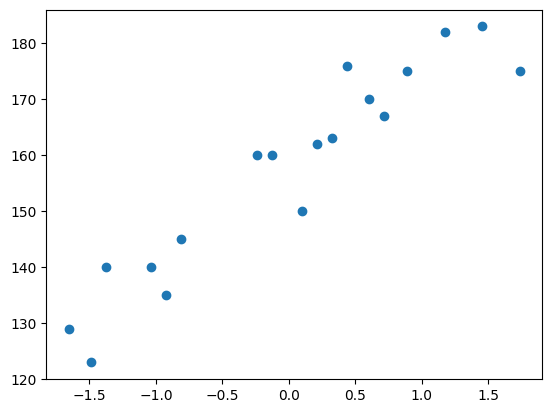

In [91]:
plt.scatter(X_train,y_train)

In [92]:
## train the model
# simple linear regression model

from sklearn.linear_model import LinearRegression

In [93]:
regressor=LinearRegression()

In [94]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
print("the slope or coefficient of weight:",regressor.coef_)
print("intercept:",regressor.intercept_)

the slope or coefficient of weight: [17.03440872]
intercept: 157.5


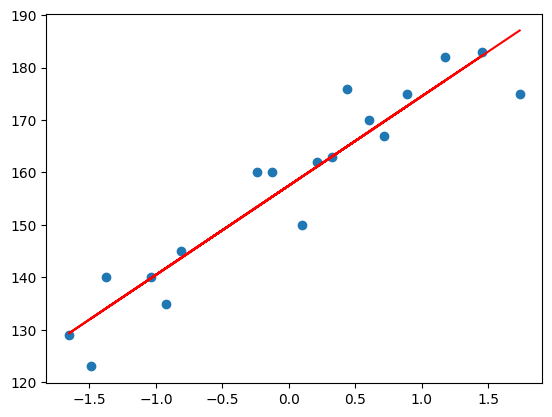

In [96]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

In [97]:
y_pred_test=regressor.predict(X_test)

In [98]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

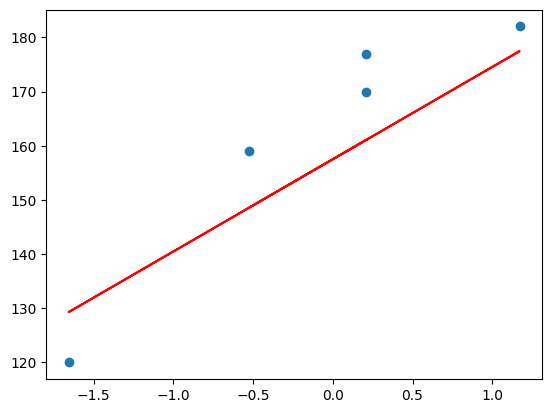

In [99]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

In [101]:
## perfommance metrices

## mse , mae , rmse
## r square and adjusted r square

from sklearn.metrics import mean_squared_error,mean_absolute_error

In [105]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(rmse)
print(mae)

109.77592599051664
10.477400726827081
9.822657814519232


In [106]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)

In [107]:
score

0.776986986042344

In [109]:
regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [110]:
# new data point weight is 80

scaled_weight=scaler.transform([[80]])
scaled_weight

d:\CSE EVERYTHING\ML with Python\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [115]:
print("the height prediction for 80kg weight:",regressor.predict(scaled_weight))

the height prediction for 80kg weight: [163.01076266]


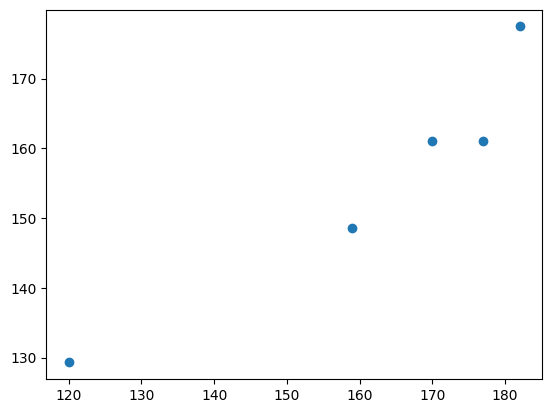

In [118]:
## assumptions
## plot a scatter plot for the prediction

plt.scatter(y_test,y_pred_test)

In [119]:
## residuals

residuals=y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

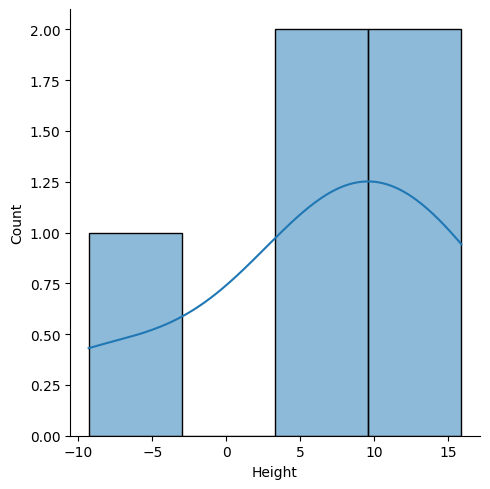

In [120]:
## plot the residuals

import seaborn as sns
sns.displot(residuals,kde=True)

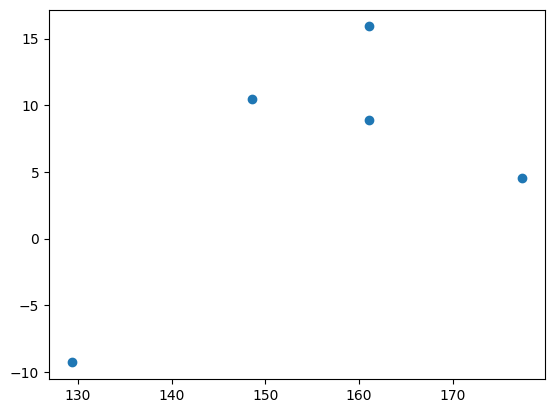

In [124]:
## must be a uniform distribution curve
plt.scatter(y_pred_test,residuals)